In [1]:
import os
import sys
os.chdir("../")
sys.path.insert(0, os.path.abspath("."))
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ldc.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

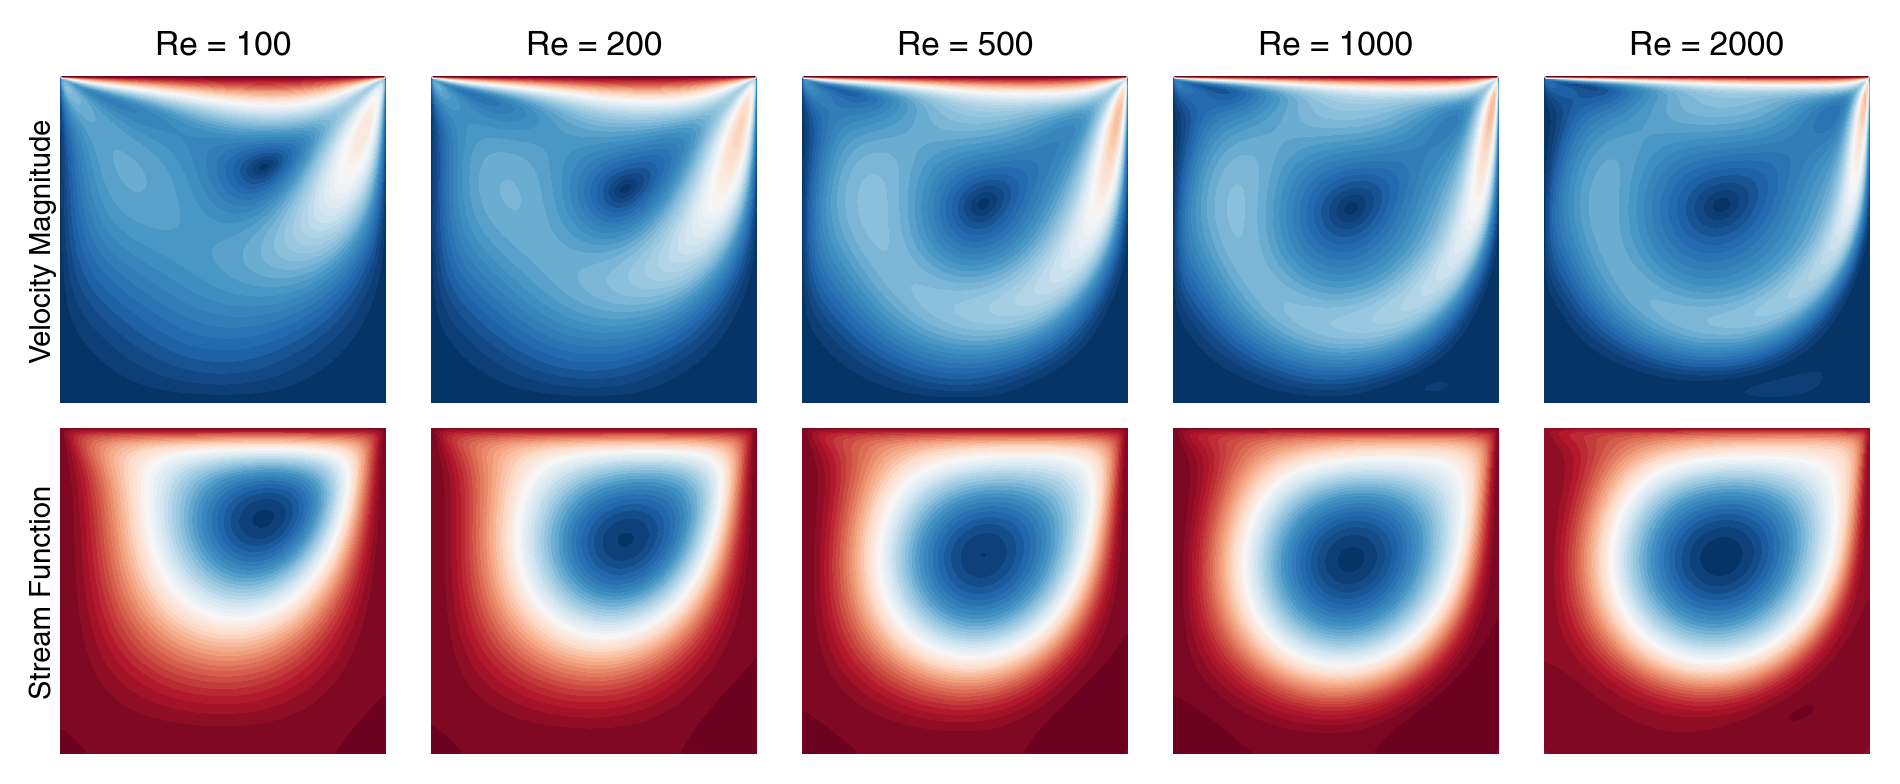

In [3]:
re_vals = [100, 200, 500, 1000, 2000]
data_paths = [f"./data/ldc/flow_fields_Re{re_val}_N128.npz" for re_val in re_vals]
# x = jnp.linspace(0, 1, 128)
# y = jnp.linspace(0, 1, 128)
# X, Y = jnp.meshgrid(x, y, indexing="xy")
data_sample = jnp.load(data_paths[0])
X = data_sample["X"]
Y = data_sample["Y"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(re_vals),
    figsize=(1.25 * len(re_vals), 1.25*2),
    constrained_layout=True,
)
for idx, (re_val, data_path) in enumerate(zip(re_vals, data_paths)):
    data = jnp.load(data_path)
    u = data["u"]
    v = data["v"]
    speed = jnp.sqrt(u**2 + v**2)
    ax = axes[0, idx]
    ax.contourf(
        X, Y, speed,
        levels=50,
        cmap="RdBu_r",
        vmin=0,
        vmax=1.0,
    )
    ax.set_axis_off()
    ax.text(
        0.5, 1.05,
        f"Re = {re_val}",
        fontsize=8,
        ha="center",
        va="bottom",
        transform=ax.transAxes,
    )
    ax.set_aspect("equal")
    
    ax = axes[1, idx]
    psi = data["psi"]
    ax.contourf(
        X, Y, psi,
        levels=50,
        cmap="RdBu_r",
    )
    ax.set_axis_off()
    ax.set_aspect("equal")
    
    if idx == 0:
        axes[0, idx].text(
            -0.05, 0.5,
            "Velocity Magnitude",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[0, idx].transAxes,
        )
        axes[1, idx].text(
            -0.05, 0.5,
            "Stream Function",
            fontsize=7,
            rotation=90,
            ha="center",
            va="center",
            transform=axes[1, idx].transAxes,
        )

In [9]:
from ldc.simplified_cvit import CViT

key = jax.random.PRNGKey(0)
model_params = configs.model_params


# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-mlplayer3/model_epoch_23000.eqx"
# model_params.update({
#     "dec_depth": 2,
#     "dec_mlp_arch": "mlp"
# })

# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-modifiedmlp_layer3/model_epoch_12000.eqx"
# model_params.update({
#     "dec_depth": 2,
# })

# weight = "/root/autodl-tmp/tf-logs/ldc/cvit/20260126-165653/model_epoch_8000.eqx"
weight = "/root/autodl-tmp/tf-logs/ldc/cvit/baseline-0126-renold100_2000/model_epoch_20000.eqx"


model_skeleton = CViT(
    key,
    **model_params,
)
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [10]:

Nx, Ny = configs.Nx, configs.Ny
# x = jnp.linspace(0, 1, Nx)
# y = jnp.linspace(0, 1, Ny)
# X, Y = jnp.meshgrid(x, y, indexing="xy") # (Ny, Nx)
coords = jnp.stack([
    X.reshape(-1),
    Y.reshape(-1)
], axis=-1)  # (Ny*Nx, 2)
target_reynold = jnp.array(configs.evaluate_on_re) # reynolds number
target_reynold = target_reynold.reshape(-1, 1)  # (B, 1)

target_reynold_normed = configs.normalize_re(target_reynold)
sols = jax.vmap(
    model, in_axes=(0, None)
)(target_reynold_normed, coords)  # (B, Ny*Nx, 3)

B, _, C = sols.shape
H = Ny
W = Nx
sols = rearrange(sols, "B (H W) C -> B C H W", H=int(H), W=int(W))  # (B, 3, H, W)
u = sols[:, 0, :, :]  # (B, H, W)
v = sols[:, 1, :, :]  # (B, H, W)
speed = jnp.sqrt(u**2 + v**2)  # (B, H, W)

# mask 左上和右上角的奇点，把u, v, speed对应位置设为0
eps = 1e-2
mask = (X > 1 - eps) & (Y > 1 - eps) | (X < eps) & (Y > 1 - eps)
# u = jnp.where(mask[None, :, :], 0.0, u)
# v = jnp.where(mask[None, :, :], 0.0, v)
# speed = jnp.where(mask[None, :, :], 0.0, speed)

Re=100, rel. L2 error: 0.113116
Re=200, rel. L2 error: 0.100457
Re=500, rel. L2 error: 0.094780
Re=1000, rel. L2 error: 0.159445
Re=2000, rel. L2 error: 0.306425
Average rel. L2 error: 0.154844


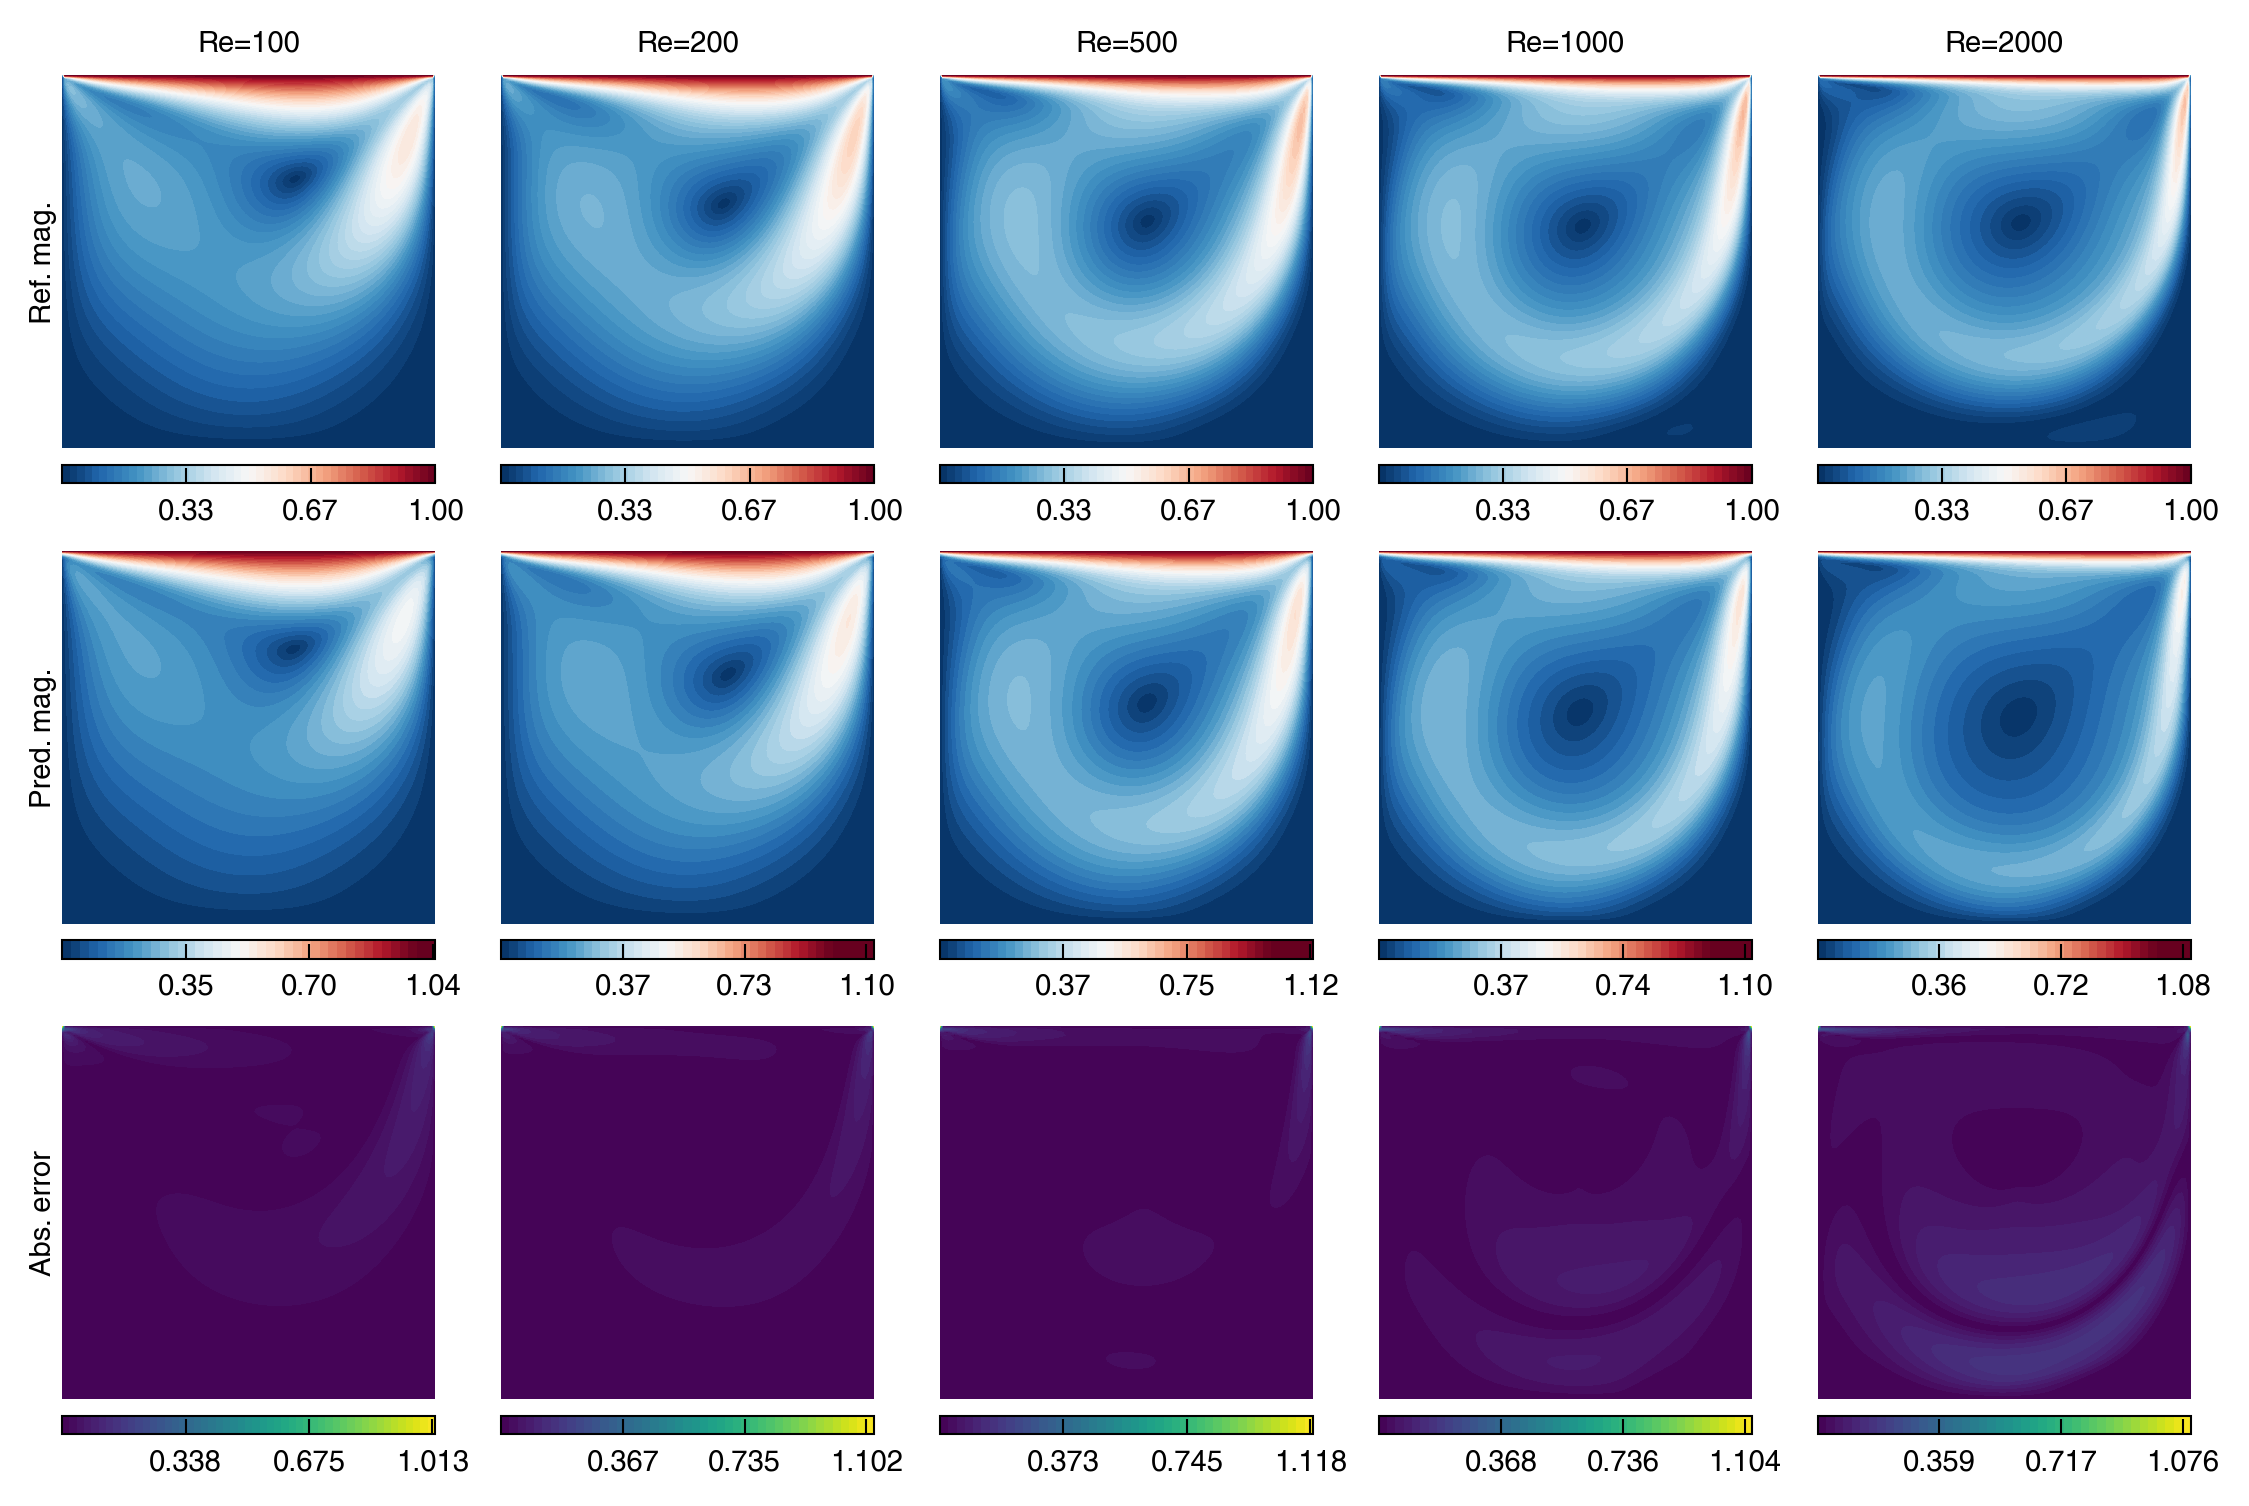

In [6]:
data_dir = configs.data_dir


fig, axes = plt.subplots(
    nrows=3,
    ncols=B,
    figsize=(1.5 * B, 5),
    subplot_kw={"aspect": "equal",},
)

total_l2 = 0
for i, this_reynold in enumerate(target_reynold):
    ax = axes[0, i]
    ax.set_axis_off()
    ref_data = jnp.load(
        f"{data_dir}/flow_fields_Re{int(this_reynold[0])}_N128.npz"
    )
    ref_u = ref_data["u"]  # (H, W)
    ref_v = ref_data["v"]  # (H, W)
    ref_speed = jnp.sqrt(ref_u**2 + ref_v**2)  # (H, W)
    
    # ! mask singularities
    # ref_u = jnp.where(mask, 0.0, ref_u)
    # ref_v = jnp.where(mask, 0.0, ref_v)
    # ref_speed = jnp.where(mask, 0.0, ref_speed)
    
    ref_cont = ax.contourf(
        X, Y, ref_speed, levels=50, cmap="RdBu_r",
        vmin=0, vmax=1.0
    )
    fig.colorbar(ref_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
                 format="%.2f", ticks=jnp.linspace(0, jnp.max(ref_speed), num=4)[1:])
    ax.text(
        0.5, 1.05, f"Re={int(this_reynold[0])}", 
        transform=ax.transAxes,
        ha="center", va="bottom",
    )
    
    ax = axes[1, i]
    ax.set_axis_off()
    pred_cont = ax.contourf(
        X, Y, speed[i], levels=50, cmap="RdBu_r",
        vmin=0, vmax=1.0
    )
    fig.colorbar(pred_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
                 format="%.2f", ticks=jnp.linspace(0, jnp.max(speed[i]), num=4)[1:])
    
    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(ref_speed - speed[i])
    diff_cont = ax.contourf(X, Y, diff, levels=50, cmap="viridis",)
    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04, orientation="horizontal",
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff), num=4)[1:]
    ) 
    
    if i == 0:
        axes[0, i].text(
            -0.05, 0.5, "Ref. mag.",
            transform=axes[0, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[1, i].text(
            -0.05, 0.5, "Pred. mag.",
            transform=axes[1, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        axes[2, i].text(
            -0.05, 0.5, "Abs. error",
            transform=axes[2, i].transAxes,
            rotation=90, ha="center", va="center",
        )
        
    # this_l2 = jnp.sqrt(jnp.mean(diff**2)) / jnp.sqrt(jnp.mean(ref_speed**2))
    this_l2_u = jnp.sqrt(jnp.mean((ref_u - u[i])**2)) / jnp.sqrt(jnp.mean(ref_u**2))
    this_l2_v = jnp.sqrt(jnp.mean((ref_v - v[i])**2)) / jnp.sqrt(jnp.mean(ref_v**2))
    this_l2 = (this_l2_u + this_l2_v) / 2
    total_l2 += this_l2 / B
    print(f"Re={int(this_reynold[0])}, rel. L2 error: {this_l2:.6f}")
print(f"Average rel. L2 error: {total_l2:.6f}")
fig.tight_layout()

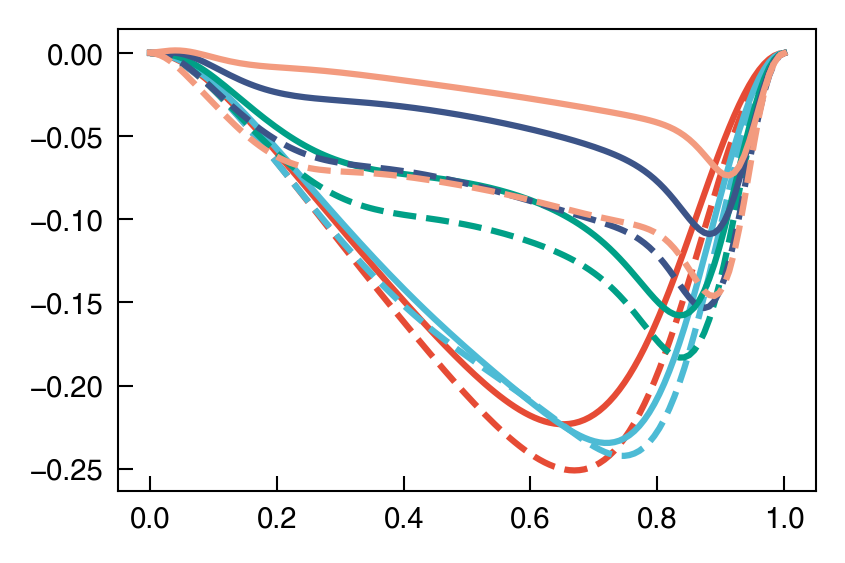

In [7]:
x = jnp.linspace(0, 1, Nx)
y = jnp.linspace(0, 1, Ny)
# 绘制 u 在 y=0.5 处的剖面图
y_index = Ny // 2  # y=0.5 对应的索引
plt.figure(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):
    ref_data = jnp.load(
        f"{data_dir}/flow_fields_Re{int(this_reynold[0])}_N128.npz"
    )
    ref_u = ref_data["u"]  # (H, W)
    plt.plot(
        x,
        ref_u[y_index, :],
        label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    plt.plot(
        x,
        u[i, y_index, :],
        label=f"Pred. Re={int(this_reynold[0])}",
        linestyle="-",
        color=f"C{i}",
    )

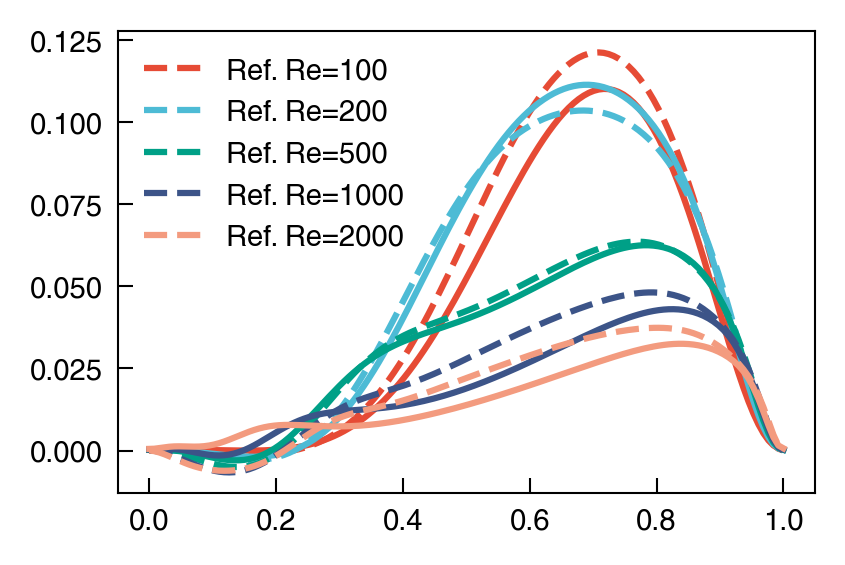

In [8]:
# 绘制 v 在 x=0.5 处的剖面图
x_index = Nx // 2  # x=0.5 对应的索引
# plt.figure(figsize=(3, 2))
fig, ax = plt.subplots(figsize=(3, 2))
for i, this_reynold in enumerate(target_reynold):
    ref_data = jnp.load(
        f"{data_dir}/flow_fields_Re{int(this_reynold[0])}_N128.npz"
    )
    ref_v = ref_data["v"]  # (H, W)
    ax.plot(
        y,
        ref_v[:, x_index],
        label=f"Ref. Re={int(this_reynold[0])}",
        linestyle="--",
        color=f"C{i}",
    )
    
    ax.plot(
        y,
        v[i, :, x_index],
        # label=f"Pred. Re={int(this_reynold[0])}",
        linestyle="-",
        color=f"C{i}",
    )
ax.legend()